# 05 — Disengagement Modeling (v2)
SpiriCom · Huawei Technologies Tunisia · PFE 2026

Consumes `churn_features_v6.parquet` (with its persisted train/test split) and
`models/churn_features_meta.json` from NB04 v2.

## Protocol
- Models: Logistic Regression (baseline), Random Forest, XGBoost — class-weighted.
- Model selection on **5-fold OOF predictions on train only**; the test set is
  touched exactly once, at the end.
- Decision threshold tuned on the OOF precision-recall curve (max F1), never on test.
- Headline metrics: **PR-AUC + lift vs the 33.8% prevalence baseline**; ROC-AUC,
  F1/precision/recall at the tuned threshold, and Brier score for calibration.

## Interpretation guardrails (write these into the PFE report)
| # | Caveat |
|---|--------|
| 1 | `is_2g_only` is **near-deterministic** (93.2% disengaged): a 2G handset cannot consume data, so it falls under the dou threshold mechanically. Present it as *structural disengagement* (actionable: device-upgrade campaigns), not as a subtle prediction. The **QoS-only ablation** below quantifies how much performance comes from network experience alone. |
| 2 | `number_of_regions` is partially an activity proxy (less usage = observed in fewer regions) — graded caution. |
| 3 | `tcp_connection_sr` (r=-0.52) and `dns_sr` (r=-0.39) are the strongest pure-QoS signals — verify with the data owner that low-activity customers don't simply have noisier success-rate measurements before presenting causally. |


In [1]:
import pandas as pd
import numpy as np
import json, joblib
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, accuracy_score, brier_score_loss, precision_recall_curve,
    roc_curve, confusion_matrix,
)
import xgboost as xgb

HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', green='#22C55E',
          amber='#F59E0B', purple='#8B5CF6', muted='#6B7280')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 120, 'savefig.dpi': 300,
                     'savefig.bbox': 'tight'})

PROC_DIR  = Path('data/processed')
MODEL_DIR = Path('models')
OUT_DIR   = Path('data/outputs')
FIG_DIR   = Path('data/outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df   = pd.read_parquet(PROC_DIR / 'churn_features_v6.parquet')
meta = json.load(open(MODEL_DIR / 'churn_features_meta.json'))
FEATURES = [c for c in meta['feature_columns'] if c in df.columns]

# Defensive: drop constants (e.g. usertype one-hot from the pre-patch NB04 run)
const = [c for c in FEATURES if df[c].nunique() <= 1]
if const:
    print(f'Dropped constant features: {const}')
    FEATURES = [c for c in FEATURES if c not in const]

tr = df[df['split'] == 'train']
te = df[df['split'] == 'test']
X_tr, y_tr = tr[FEATURES], tr['churn'].astype(int)
X_te, y_te = te[FEATURES], te['churn'].astype(int)
prevalence = float(y_tr.mean())
print(f'Train {len(tr):,} | Test {len(te):,} | features {len(FEATURES)} '
      f'| prevalence {prevalence*100:.1f}%')


Dropped constant features: ['dou_total_imputed', 'duration_imputed']
Train 1,924 | Test 642 | features 57 | prevalence 33.8%


## 1 — Models

In [2]:
neg, pos = int((y_tr == 0).sum()), int((y_tr == 1).sum())

MODELS = {
    'logistic_regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('lr',  LogisticRegression(max_iter=3000, class_weight='balanced',
                                   random_state=42)),
    ]),
    'random_forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('rf',  RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                       class_weight='balanced',
                                       random_state=42, n_jobs=-1)),
    ]),
    'xgboost': xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.06,
        subsample=0.85, colsample_bytree=0.8,
        scale_pos_weight=neg / pos,
        eval_metric='aucpr', random_state=42, n_jobs=-1, verbosity=0,
    ),
}
print('Models:', list(MODELS))
print(f'scale_pos_weight (XGB): {neg/pos:.2f}')


Models: ['logistic_regression', 'random_forest', 'xgboost']
scale_pos_weight (XGB): 1.96


## 2 — 5-fold OOF comparison on train (test untouched)

In [3]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)

def tune_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-9)
    return float(thr[int(np.nanargmax(f1))])

oof_results = {}
for name, model in MODELS.items():
    proba = cross_val_predict(model, X_tr, y_tr, cv=cv,
                              method='predict_proba', n_jobs=-1)[:, 1]
    thr = tune_threshold(y_tr, proba)
    oof_results[name] = {
        'oof_roc_auc': roc_auc_score(y_tr, proba),
        'oof_pr_auc' : average_precision_score(y_tr, proba),
        'oof_f1'     : f1_score(y_tr, (proba >= thr).astype(int)),
        'threshold'  : thr,
    }
    r = oof_results[name]
    print(f'{name:<22s} OOF ROC-AUC {r["oof_roc_auc"]:.4f} | '
          f'PR-AUC {r["oof_pr_auc"]:.4f} '
          f'(lift x{r["oof_pr_auc"]/prevalence:.2f}) | '
          f'F1@{thr:.2f} {r["oof_f1"]:.4f}')

best_name = max(oof_results, key=lambda k: oof_results[k]['oof_pr_auc'])
print(f'\nSelected on OOF PR-AUC: {best_name}')


logistic_regression    OOF ROC-AUC 0.8337 | PR-AUC 0.8131 (lift x2.40) | F1@0.58 0.7037
random_forest          OOF ROC-AUC 0.8537 | PR-AUC 0.8333 (lift x2.46) | F1@0.54 0.7403
xgboost                OOF ROC-AUC 0.8313 | PR-AUC 0.8187 (lift x2.42) | F1@0.65 0.7306

Selected on OOF PR-AUC: random_forest


## 3 — Final fit + single test evaluation

In [4]:
test_results = {}
fitted = {}
for name, model in MODELS.items():
    model.fit(X_tr, y_tr)
    fitted[name] = model
    proba = model.predict_proba(X_te)[:, 1]
    thr   = oof_results[name]['threshold']      # tuned on OOF, never on test
    pred  = (proba >= thr).astype(int)
    test_results[name] = {
        'roc_auc'  : roc_auc_score(y_te, proba),
        'pr_auc'   : average_precision_score(y_te, proba),
        'lift'     : average_precision_score(y_te, proba) / float(y_te.mean()),
        'f1'       : f1_score(y_te, pred),
        'precision': precision_score(y_te, pred),
        'recall'   : recall_score(y_te, pred),
        'accuracy' : accuracy_score(y_te, pred),
        'brier'    : brier_score_loss(y_te, proba),
        'threshold': thr,
        '_proba'   : proba,
    }

table = pd.DataFrame({k: {m: round(v, 4) for m, v in r.items()
                          if not m.startswith('_')}
                      for k, r in test_results.items()}).T
print('=== TEST SET (single evaluation) ===')
print(table.to_string())
print(f'\nBest by test PR-AUC: '
      f'{table["pr_auc"].astype(float).idxmax()} '
      f'(selection was made on OOF: {best_name})')


c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\c50057188\Desktop\PFE_Ouerghi\venv

=== TEST SET (single evaluation) ===
                     roc_auc  pr_auc    lift      f1  precision  recall  accuracy   brier  threshold
logistic_regression   0.8305  0.8158  2.4135  0.7071     0.8272  0.6175    0.8271  0.1386     0.5814
random_forest         0.8523  0.8252  2.4415  0.7342     0.9054  0.6175    0.8489  0.1219     0.5355
xgboost               0.8166  0.7967  2.3569  0.7075     0.8944  0.5853    0.8364  0.1395     0.6523

Best by test PR-AUC: random_forest (selection was made on OOF: random_forest)


## 4 — ROC / PR curves + confusion matrix of the selected model

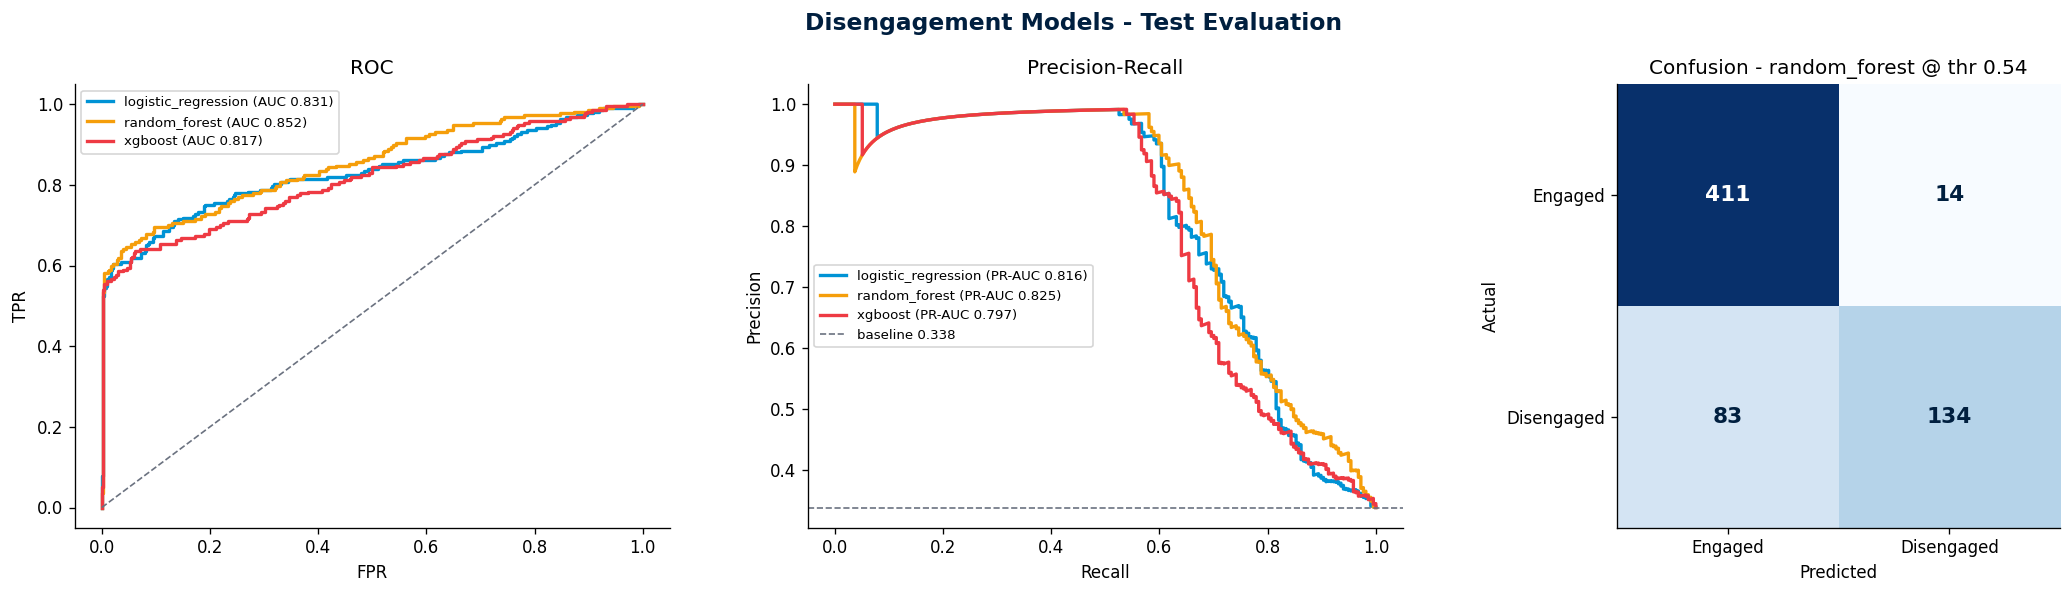

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Disengagement Models - Test Evaluation', fontsize=14,
             fontweight='bold', color=HW['navy'])
colors = {'logistic_regression': HW['blue'],
          'random_forest': HW['amber'], 'xgboost': HW['red']}

ax = axes[0]
for name, r in test_results.items():
    fpr, tpr, _ = roc_curve(y_te, r['_proba'])
    ax.plot(fpr, tpr, color=colors[name], lw=2,
            label=f'{name} (AUC {r["roc_auc"]:.3f})')
ax.plot([0, 1], [0, 1], color=HW['muted'], ls='--', lw=1)
ax.set_title('ROC'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=8)

ax2 = axes[1]
for name, r in test_results.items():
    prec, rec, _ = precision_recall_curve(y_te, r['_proba'])
    ax2.plot(rec, prec, color=colors[name], lw=2,
             label=f'{name} (PR-AUC {r["pr_auc"]:.3f})')
ax2.axhline(float(y_te.mean()), color=HW['muted'], ls='--', lw=1,
            label=f'baseline {float(y_te.mean()):.3f}')
ax2.set_title('Precision-Recall'); ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision'); ax2.legend(fontsize=8)

ax3 = axes[2]
r = test_results[best_name]
cm = confusion_matrix(y_te, (r['_proba'] >= r['threshold']).astype(int))
im = ax3.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax3.text(j, i, f'{v:,}', ha='center', va='center', fontsize=13,
             fontweight='bold',
             color='white' if v > cm.max() / 2 else HW['navy'])
ax3.set_xticks([0, 1]); ax3.set_xticklabels(['Engaged', 'Disengaged'])
ax3.set_yticks([0, 1]); ax3.set_yticklabels(['Engaged', 'Disengaged'])
ax3.set_xlabel('Predicted'); ax3.set_ylabel('Actual')
ax3.set_title(f'Confusion - {best_name} @ thr {r["threshold"]:.2f}')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_01_model_evaluation.png', dpi=300,
            bbox_inches='tight')
plt.show()


## 5 — QoS-only ablation (guardrail #1)
Same XGBoost without the structural device/capability features and without
mobility-proxy features. The gap between this and the full model is exactly how
much performance comes from "a 2G phone can't use data".

In [6]:
STRUCTURAL = ([c for c in FEATURES if c.startswith(('brand_', 'tertype_'))]
              + ['is_2g_only', 'has_3g', 'has_lte', 'has_nr',
                 'number_of_regions'])
QOS_FEATURES = [c for c in FEATURES if c not in STRUCTURAL]
print(f'QoS-only feature set: {len(QOS_FEATURES)} of {len(FEATURES)}')

xgb_qos = xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.06,
    subsample=0.85, colsample_bytree=0.8, scale_pos_weight=neg / pos,
    eval_metric='aucpr', random_state=42, n_jobs=-1, verbosity=0)

proba_oof_q = cross_val_predict(xgb_qos, X_tr[QOS_FEATURES], y_tr, cv=cv,
                                method='predict_proba', n_jobs=-1)[:, 1]
thr_q = tune_threshold(y_tr, proba_oof_q)
xgb_qos.fit(X_tr[QOS_FEATURES], y_tr)
proba_q = xgb_qos.predict_proba(X_te[QOS_FEATURES])[:, 1]

ablation = {
    'roc_auc': roc_auc_score(y_te, proba_q),
    'pr_auc' : average_precision_score(y_te, proba_q),
    'f1'     : f1_score(y_te, (proba_q >= thr_q).astype(int)),
}
full = test_results['xgboost']
print('\n              full XGB   QoS-only   delta')
for m in ['roc_auc', 'pr_auc', 'f1']:
    print(f'{m:<10s} {full[m]:>9.4f} {ablation[m]:>10.4f} '
          f'{full[m]-ablation[m]:>+8.4f}')
print('\nReport line: "network experience alone (QoS-only) reaches '
      f'PR-AUC {ablation["pr_auc"]:.3f}; adding device/capability '
      f'features brings it to {full["pr_auc"]:.3f}."')


QoS-only feature set: 39 of 57

              full XGB   QoS-only   delta
roc_auc       0.8166     0.8058  +0.0108
pr_auc        0.7967     0.7945  +0.0021
f1            0.7075     0.7268  -0.0192

Report line: "network experience alone (QoS-only) reaches PR-AUC 0.795; adding device/capability features brings it to 0.797."


## 6 — Feature importance of the selected model (full SHAP in NB06)

c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\c50057188\Desktop\PFE_Ouerghi\venv

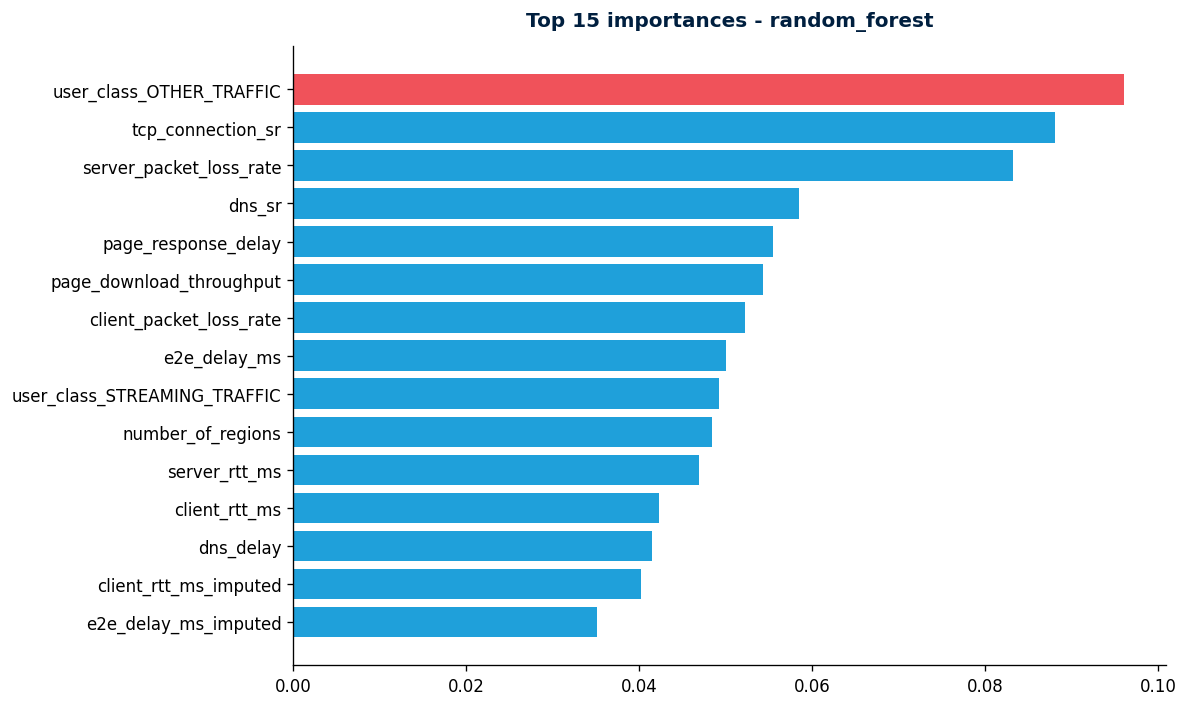

user_class_OTHER_TRAFFIC        0.0961
tcp_connection_sr               0.0880
server_packet_loss_rate         0.0832
dns_sr                          0.0585
page_response_delay             0.0555
page_download_throughput        0.0543
client_packet_loss_rate         0.0522
e2e_delay_ms                    0.0501
user_class_STREAMING_TRAFFIC    0.0493
number_of_regions               0.0485
server_rtt_ms                   0.0469
client_rtt_ms                   0.0423
dns_delay                       0.0415
client_rtt_ms_imputed           0.0403
e2e_delay_ms_imputed            0.0351


In [7]:
best_model = fitted[best_name]
if best_name == 'xgboost':
    imp = pd.Series(best_model.feature_importances_, index=FEATURES)
elif best_name == 'random_forest':
    imp = pd.Series(best_model.named_steps['rf'].feature_importances_,
                    index=FEATURES)
else:
    imp = pd.Series(np.abs(best_model.named_steps['lr'].coef_[0]),
                    index=FEATURES)

top = imp.sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(10, 6))
bar_c = [HW['red'] if v == top.max() else HW['blue'] for v in top]
ax.barh(top.index, top.values, color=bar_c, alpha=0.88)
ax.set_title(f'Top 15 importances - {best_name}', pad=12,
             color=HW['navy'], fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_02_feature_importance.png', dpi=300,
            bbox_inches='tight')
plt.show()
print(top.sort_values(ascending=False).round(4).to_string())


## 7 — Save artifacts for the FastAPI layer

In [8]:
best = test_results[best_name]
joblib.dump(fitted[best_name], MODEL_DIR / 'disengagement_model_v6.joblib')
json.dump(FEATURES, open(MODEL_DIR / 'disengagement_features.json', 'w'))

# Test-set risk scores for the dashboard "Churn Risk" demo table
risk = pd.DataFrame({
    'msisdn': te['msisdn'].values,
    'risk'  : np.round(best['_proba'], 4),
})
risk['risk_band'] = pd.cut(risk['risk'], [0, .33, .66, 1.0],
                           labels=['low', 'medium', 'high'],
                           include_lowest=True)
risk.sort_values('risk', ascending=False) \
    .to_parquet(MODEL_DIR / 'disengagement_risk_scores.parquet', index=False)

metrics_json = {
    'generated_at' : datetime.now().isoformat(),
    'label_version': 'v6 (disengagement segmentation - see churn_eda_v6.json)',
    'selected_model': best_name,
    'selection_rule': 'OOF PR-AUC on train (5-fold), test touched once',
    'baseline_prevalence': prevalence,
    'test_metrics': {k: {m: round(float(v), 4) for m, v in r.items()
                         if not m.startswith('_')}
                     for k, r in test_results.items()},
    'qos_only_ablation': {m: round(float(v), 4) for m, v in ablation.items()},
    'interpretation_guardrails': [
        'is_2g_only is near-deterministic (structural disengagement)',
        'number_of_regions partially proxies activity volume',
        'tcp_connection_sr / dns_sr strength to be validated with data owner',
    ],
    'artifacts': {
        'model'   : str(MODEL_DIR / 'disengagement_model_v6.joblib'),
        'features': str(MODEL_DIR / 'disengagement_features.json'),
        'scores'  : str(MODEL_DIR / 'disengagement_risk_scores.parquet'),
    },
}
jp = OUT_DIR / 'disengagement_model_metrics.json'
json.dump(metrics_json, open(jp, 'w'), indent=2)
print(f'Saved: {jp}')
print(json.dumps({k: v for k, v in metrics_json.items()
                  if k != 'test_metrics'}, indent=2))
print('\nHigh-risk preview (top 10):')
print(risk.sort_values('risk', ascending=False).head(10).to_string(index=False))
print('\nNext -> 06: SHAP on the selected model; then sync the dashboard')
print('(Forecasting TRAINING constant + churn tiles wording).')


Saved: data\outputs\disengagement_model_metrics.json
{
  "generated_at": "2026-06-12T09:04:11.666152",
  "label_version": "v6 (disengagement segmentation - see churn_eda_v6.json)",
  "selected_model": "random_forest",
  "selection_rule": "OOF PR-AUC on train (5-fold), test touched once",
  "baseline_prevalence": 0.33835758835758833,
  "qos_only_ablation": {
    "roc_auc": 0.8058,
    "pr_auc": 0.7945,
    "f1": 0.7268
  },
  "interpretation_guardrails": [
    "is_2g_only is near-deterministic (structural disengagement)",
    "number_of_regions partially proxies activity volume",
    "tcp_connection_sr / dns_sr strength to be validated with data owner"
  ],
  "artifacts": {
    "model": "models\\disengagement_model_v6.joblib",
    "features": "models\\disengagement_features.json",
    "scores": "models\\disengagement_risk_scores.parquet"
  }
}

High-risk preview (top 10):
  msisdn   risk risk_band
90475964 1.0000      high
96468407 1.0000      high
97615203 1.0000      high
 9645237 0.9

C:\Users\c50057188\AppData\Local\Temp\ipykernel_2688\4089413933.py:3: ResourceWarning: unclosed file <_io.TextIOWrapper name='models\\disengagement_features.json' mode='w' encoding='cp1252'>
  json.dump(FEATURES, open(MODEL_DIR / 'disengagement_features.json', 'w'))
C:\Users\c50057188\AppData\Local\Temp\ipykernel_2688\4089413933.py:38: ResourceWarning: unclosed file <_io.TextIOWrapper name='data\\outputs\\disengagement_model_metrics.json' mode='w' encoding='cp1252'>
  json.dump(metrics_json, open(jp, 'w'), indent=2)
